In [79]:
import json
import os

# Đường dẫn từ thư mục 'preprocessing and eda' trỏ về 'dataset/ngoài quận 5'
folder_path = '../dataset/ngoài quận 5/'

# Thay vì dùng glob lấy tất cả, ta CHỈ ĐỊNH ĐÍCH DANH 4 file cần gộp
target_files = [
    '001-100.json',
    '101_200.json',
    '201-300.json',
    '301-400.json'
]

# Nối dính file với folder_path để tạo đường dẫn hoàn chỉnh
json_files = [os.path.join(folder_path, file_name) for file_name in target_files]

merged_data = []

# Đọc và gộp dữ liệu từ từng file
for file_path in json_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            # Dữ liệu từ file JSON có dạng list các dictionary
            if isinstance(data, list):
                merged_data.extend(data)
            else:
                merged_data.append(data)
    except Exception as e:
        print(f"Lỗi khi đọc file {file_path}: {e}")

# Đường dẫn lưu file sau khi gộp
output_file = '../dataset/ngoài quận 5/001-400.json'

# Lưu data đã gộp ra một file mới
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(merged_data, f, ensure_ascii=False, indent=4)

print(f"Đã gộp thành công {len(target_files)} file chỉ định.")
print(f"Tổng số records (nhà hàng) sau khi gộp: {len(merged_data)}")
print(f"File tổng hợp được cập nhật và lưu tại: {output_file}")


Đã gộp thành công 4 file chỉ định.
Tổng số records (nhà hàng) sau khi gộp: 400
File tổng hợp được cập nhật và lưu tại: ../dataset/ngoài quận 5/001-400.json


# Chuyển đổi dữ liệu

In [80]:
import pandas as pd
import json

# Đường dẫn file JSON
file_path = r'C:\Users\ADMIN\Documents\Chuyen Nganh\HK2\Nhập môn học máy\Lab 1 - ML\ML-Lab1-Restaurant\dataset\ngoài quận 5\001-400.json'

# Đọc dữ liệu JSON
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Tạo 2 list riêng biệt để chứa dữ liệu
restaurants_data = []
reviews_data = []

# Duyệt qua từng nhà hàng
for restaurant in data:
    restaurant_name = restaurant.get('name')
    
    # 1. Thu thập dữ liệu cho bảng Nhà hàng (Restaurants)
    restaurants_data.append({
        'name': restaurant_name,
        'avg_rating': restaurant.get('avg_rating'),
        'review_count': restaurant.get('review_count'),
        'url_source': restaurant.get('url_source') # Trích xuất thêm link gốc nếu có
    })
    
    # 2. Thu thập dữ liệu cho bảng Đánh Giá (Reviews)
    reviews = restaurant.get('reviews', [])
    for review in reviews:
        features = review.get('features', {})
        
        reviews_data.append({
            'restaurant_name': restaurant_name, # Đóng vai trò là khóa ngoại (foreign key) để liên kết
            'reviewer': review.get('reviewer'),
            'rating': review.get('rating'),
            'time': review.get('time'),
            'comment': review.get('comment'),
            'food_rating': features.get('Đồ ăn'),
            'service_rating': features.get('Dịch vụ'),
            'atmosphere_rating': features.get('Bầu không khí')
        })

# Chuyển đổi thành Pandas DataFrame
df_restaurants = pd.DataFrame(restaurants_data)
df_restaurants['avg_rating'] = pd.to_numeric(df_restaurants['avg_rating'], errors='coerce') / 10
df_restaurants['review_count'] = df_restaurants['review_count'].astype('Int64')
df_reviews = pd.DataFrame(reviews_data)

# Chuyển tất cả điểm thành số nguyên
numeric_review_cols = ['rating', 'food_rating', 'service_rating', 'atmosphere_rating']
for col in numeric_review_cols:
    df_reviews[col] = pd.to_numeric(df_reviews[col], errors='coerce').astype('Int64')

# --- Kiểm tra kết quả ---
print("Kích thước bảng Nhà hàng (df_restaurants):", df_restaurants.shape)
display(df_restaurants.head(3)) # Có thể đổi thành print() nếu bạn không dùng Jupyter

print("\nKích thước bảng Đánh giá (df_reviews):", df_reviews.shape)
display(df_reviews.head(3))


Kích thước bảng Nhà hàng (df_restaurants): (400, 4)


,name,avg_rating,review_count,url_source
0,Ông Mập BBQ - CN Sư Vạn Hạnh,4.8,373,https://www.google.com/maps/place/%C3%94ng+M%E...
1,Ăn Cơm Uống Nước - Thai Bistro & Coffee,4.6,1415,https://www.google.com/maps/place/%C4%82n+C%C6...
2,Ăn Cơm Uống Nước Garden,4.8,1697,https://www.google.com/maps/place/%C4%82n+C%C6...



Kích thước bảng Đánh giá (df_reviews): (16391, 8)


,restaurant_name,reviewer,rating,time,comment,food_rating,service_rating,atmosphere_rating
0,Ông Mập BBQ - CN Sư Vạn Hạnh,Trang Huynh,3,4 tháng trước,Trước khi đến quán đã xem thực đơn và thấy giá...,3,4,5
1,Ông Mập BBQ - CN Sư Vạn Hạnh,Hào Nguyễn Anh,4,2 tháng trước,"Nướng Hàn ngon nha mng, ăn cũng ok, không gian...",4,4,4
2,Ông Mập BBQ - CN Sư Vạn Hạnh,Thanh Thúy Nguyễn,5,5 tháng trước,"Lần đầu tiên tới quán. Mẹ mình khá khó tính, c...",4,5,4


--- 20 Mốc thời gian phổ biến nhất ---
time
một năm trước                         3027
2 năm trước                           1331
3 tháng trước                         1248
2 tháng trước                         1218
một tháng trước                       1126
5 tháng trước                         1059
4 tháng trước                          979
6 tháng trước                          836
7 tháng trước                          686
8 tháng trước                          659
3 năm trước                            623
9 tháng trước                          451
11 tháng trước                         443
6 năm trước                            410
10 tháng trước                         407
5 năm trước                            340
4 năm trước                            285
3 tuần trước                           151
Thời gian chỉnh sửa: một năm trước     133
7 năm trước                            127
Name: count, dtype: int64


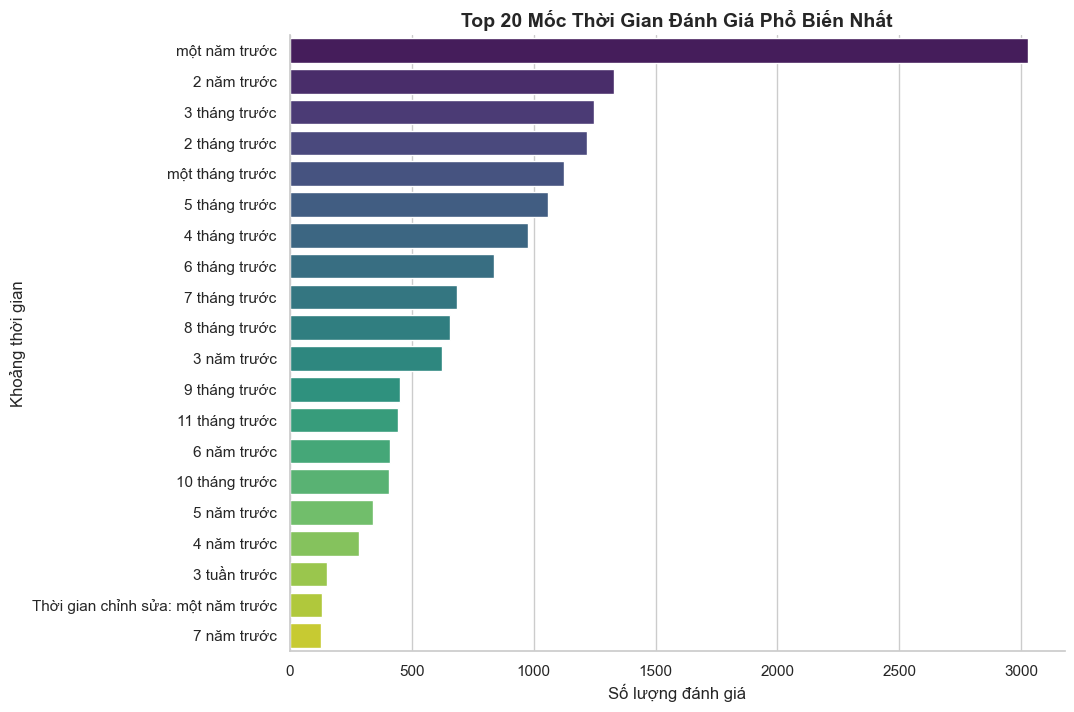

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. In ra 20 mốc thời gian phổ biến nhất dưới dạng text
print("--- 20 Mốc thời gian phổ biến nhất ---")
print(df_reviews['time'].value_counts().head(20))

# 2. Vẽ biểu đồ Bar Chart dạng ngang (Top 20)
plt.figure(figsize=(10, 8))
time_counts = df_reviews['time'].value_counts().head(20)

sns.barplot(
    x=time_counts.values, 
    y=time_counts.index,
    hue=time_counts.index,  # <--- Thêm dòng này
    legend=False,           # <--- Kèm theo dòng này
    palette='viridis' 
)

plt.title('Top 20 Mốc Thời Gian Đánh Giá Phổ Biến Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng đánh giá', fontsize=12)
plt.ylabel('Khoảng thời gian', fontsize=12)

# Chống trùng lặp khung bao quanh biểu đồ (tuỳ chọn cho đẹp)
sns.despine()

plt.show()


## Tiền xử lý cột time thành số lượng ngày từ khi comment đến khi hiện tại

In [82]:
import re

def convert_time_to_days(time_str):
    if pd.isna(time_str):
        return None
        
    s = str(time_str).lower()
    s = s.replace("thời gian chỉnh sửa:", "").strip()
    s = s.replace("một", "1").replace("vài", "1")
    
    nums = re.findall(r'\d+', s)
    if not nums:
        return 1 
    
    num = int(nums[0])
    
    if 'năm' in s:
        return num * 365
    elif 'tháng' in s:
        return num * 30
    elif 'tuần' in s:
        return num * 7
    elif 'ngày' in s:
        return num
    elif 'giờ' in s or 'phút' in s or 'giây' in s:
        return 1 
    return None

# Áp dụng thay thế trực tiếp vào cột 'time' và ép kiểu dữ liệu sang số nguyên
df_reviews['time'] = df_reviews['time'].apply(convert_time_to_days).astype('Int64')

# Đổi lại tên cột thành 'days_ago' cho dễ gợi nhớ ngữ nghĩa của con số
df_reviews.rename(columns={'time': 'days_ago'}, inplace=True)

# Kiểm tra lại Dataframe
print("Vừa chuyển đổi thành công. Dữ liệu đã biến thành số ngày!")
display(df_reviews.head())


Vừa chuyển đổi thành công. Dữ liệu đã biến thành số ngày!


,restaurant_name,reviewer,rating,days_ago,comment,food_rating,service_rating,atmosphere_rating
0,Ông Mập BBQ - CN Sư Vạn Hạnh,Trang Huynh,3,120,Trước khi đến quán đã xem thực đơn và thấy giá...,3,4,5
1,Ông Mập BBQ - CN Sư Vạn Hạnh,Hào Nguyễn Anh,4,60,"Nướng Hàn ngon nha mng, ăn cũng ok, không gian...",4,4,4
2,Ông Mập BBQ - CN Sư Vạn Hạnh,Thanh Thúy Nguyễn,5,150,"Lần đầu tiên tới quán. Mẹ mình khá khó tính, c...",4,5,4
3,Ông Mập BBQ - CN Sư Vạn Hạnh,nhi lam,5,90,"Món ăn ngon, có món da heo nướng đặc biệt . Kh...",5,5,4
4,Ông Mập BBQ - CN Sư Vạn Hạnh,02 - Võ Ngọc Tường Vy,5,60,Đồ ăn tươi và ngon. Đặc biệt là da heo nướng. ...,5,5,4


In [83]:
import os

# Đường dẫn thư mục lưu trữ dữ liệu (đi từ thư mục hiện tại của notebook)
save_dir = '../dataset/preprocessed'

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"-> Đã tạo thư mục: {save_dir}")

# 1. Lưu bảng Nhà Hàng (df_restaurants)
restaurants_file = os.path.join(save_dir, 'cleaned_restaurants.csv')
df_restaurants.to_csv(restaurants_file, index=False, encoding='utf-8-sig')
print(f"-> Đã lưu dữ liệu Nhà Hàng tại: {restaurants_file}")

# 2. Lưu bảng Đánh Giá (df_reviews)
reviews_file = os.path.join(save_dir, 'cleaned_reviews.csv')
df_reviews.to_csv(reviews_file, index=False, encoding='utf-8-sig')
print(f"-> Đã lưu dữ liệu Đánh Giá tại: {reviews_file}")

# Kiểm tra nhanh kích thước file sau khi lưu để an tâm
print(f"\n--- XÁC NHẬN ---")
print(f"- Nhà hàng: {df_restaurants.shape[0]} dòng.")
print(f"- Đánh giá: {df_reviews.shape[0]} dòng.")


-> Đã lưu dữ liệu Nhà Hàng tại: ../dataset/preprocessed\cleaned_restaurants.csv
-> Đã lưu dữ liệu Đánh Giá tại: ../dataset/preprocessed\cleaned_reviews.csv

--- XÁC NHẬN ---
- Nhà hàng: 400 dòng.
- Đánh giá: 16391 dòng.


# EDA nhà hàng

## Phân phối Điểm đánh giá (Average Rating Distribution)

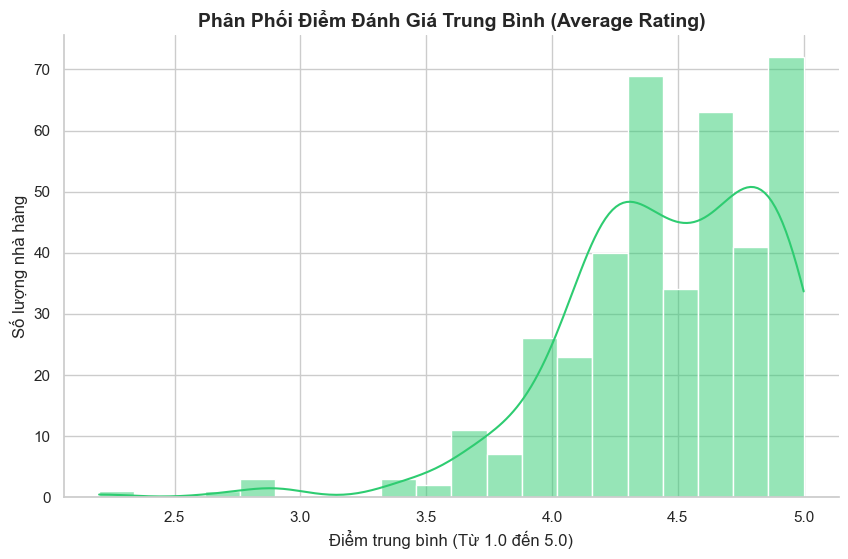

--- THỐNG KÊ RATING ---
- Điểm tập trung nhiều nhất ở quanh mức: 4.5 / 5.0
- Số lượng nhà hàng đạt điểm tuyệt đối 5.0 là: 35 (chiếm 8.75%)
- Số lượng nhà hàng bị đánh giá thấp (<3.0) là: 5 (chiếm 1.25%)


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt kích thước và style chung
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ KDE kết hợp Histogram
plt.figure()
sns.histplot(df_restaurants['avg_rating'].dropna(), bins=20, kde=True, color='#2ecc71')
plt.title('Phân Phối Điểm Đánh Giá Trung Bình (Average Rating)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm trung bình (Từ 1.0 đến 5.0)', fontsize=12)
plt.ylabel('Số lượng nhà hàng', fontsize=12)
sns.despine()
plt.show()

# Phân tích thống kê & Trả lời câu hỏi
total_restaurants = len(df_restaurants)
perfect_5_0 = len(df_restaurants[df_restaurants['avg_rating'] == 5.0])
below_3_0 = len(df_restaurants[df_restaurants['avg_rating'] < 3.0])
median_rating = df_restaurants['avg_rating'].median()

print("--- THỐNG KÊ RATING ---")
print(f"- Điểm tập trung nhiều nhất ở quanh mức: {median_rating} / 5.0")
print(f"- Số lượng nhà hàng đạt điểm tuyệt đối 5.0 là: {perfect_5_0} (chiếm {perfect_5_0/total_restaurants*100:.2f}%)")
print(f"- Số lượng nhà hàng bị đánh giá thấp (<3.0) là: {below_3_0} (chiếm {below_3_0/total_restaurants*100:.2f}%)")


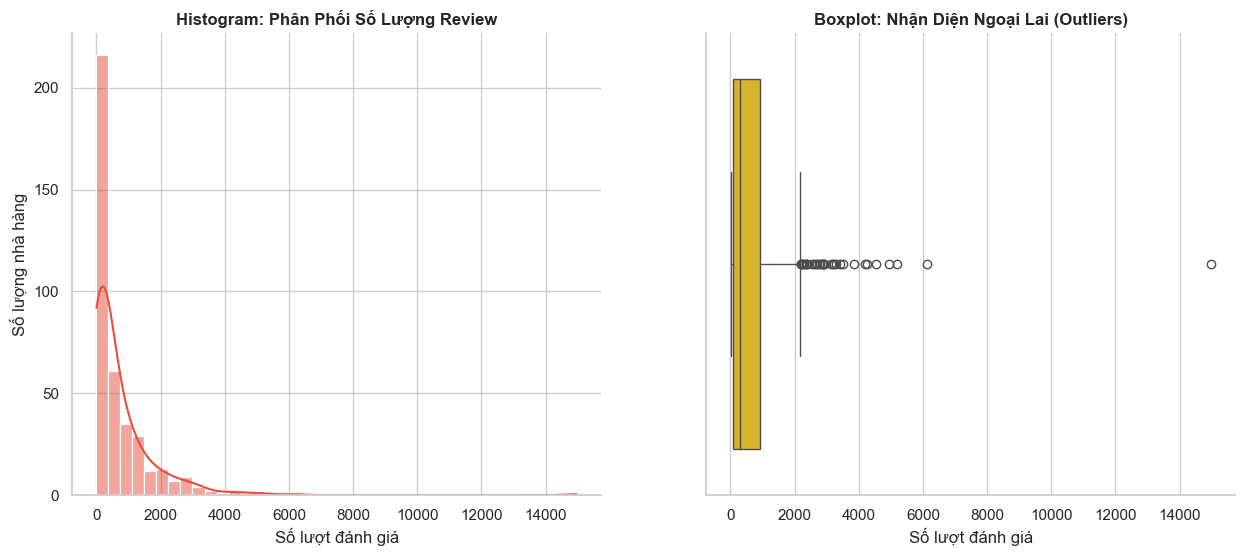

--- THỐNG KÊ SỐ LƯỢNG ĐÁNH GIÁ ---
- Lượng review trung bình / 1 nhà hàng là: 720.1 đánh giá.
- Quy luật Pareto: Top 20% nhà hàng dẫn đầu chiếm tới 66.7% tổng số tiếng nói trên thị trường!


In [85]:
# Vẽ 2 biểu đồ liền kề
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Histogram (dùng thang Log cho trục X nếu dữ liệu lệch quá to)
sns.histplot(df_restaurants['review_count'].dropna(), bins=40, color='#e74c3c', kde=True, ax=ax[0])
ax[0].set_title('Histogram: Phân Phối Số Lượng Review', fontweight='bold')
ax[0].set_xlabel('Số lượt đánh giá')
ax[0].set_ylabel('Số lượng nhà hàng')

# Boxplot
sns.boxplot(x=df_restaurants['review_count'].dropna(), color='#f1c40f', ax=ax[1])
ax[1].set_title('Boxplot: Nhận Diện Ngoại Lai (Outliers)', fontweight='bold')
ax[1].set_xlabel('Số lượt đánh giá')

sns.despine()
plt.show()

# Phân tích thống kê & Trả lời câu hỏi
avg_review = df_restaurants['review_count'].mean()
sum_reviews = df_restaurants['review_count'].sum()

print("--- THỐNG KÊ SỐ LƯỢNG ĐÁNH GIÁ ---")
print(f"- Lượng review trung bình / 1 nhà hàng là: {avg_review:.1f} đánh giá.")

# Kiểm tra quy luật Pareto (20% nhà hàng top đầu chiếm bao nhiêu % tổng Review Toàn Thị Trường)
top_20_percent = int(total_restaurants * 0.2)
top_20_hot = df_restaurants.nlargest(top_20_percent, 'review_count')
pareto_percentage = top_20_hot['review_count'].sum() / sum_reviews * 100

print(f"- Quy luật Pareto: Top 20% nhà hàng dẫn đầu chiếm tới {pareto_percentage:.1f}% tổng số tiếng nói trên thị trường!")


In [86]:
# --- 1. KIỂM TRA VÀ XÓA TRÙNG LẶP BẢNG NHÀ HÀNG ---
print(f"Kích thước bảng Nhà Hàng ban đầu: {df_restaurants.shape[0]} dòng")

# Tìm các dòng trùng lặp tuyệt đối (3 thông số)
is_duplicated_res = df_restaurants.duplicated(subset=['name', 'avg_rating', 'review_count'], keep='first')
num_duplicates_res = is_duplicated_res.sum()

if num_duplicates_res > 0:
    print(f"Phát hiện {num_duplicates_res} dòng trùng lặp. Đang tiến hành xóa...")
    df_restaurants = df_restaurants.drop_duplicates(subset=['name', 'avg_rating', 'review_count'], keep='first')
    df_restaurants = df_restaurants.reset_index(drop=True)
    print(f"Đã dọn dẹp xong. Kích thước mới: {df_restaurants.shape[0]} dòng")
else:
    print("Không có dữ liệu trùng lặp.")



# --- 2. KIỂM TRA VÀ XÓA TRÙNG LẶP BẢNG ĐÁNH GIÁ ---
print(f"Kích thước bảng Đánh Giá ban đầu: {df_reviews.shape[0]} dòng")

# Tìm các dòng trùng lặp dựa trên quán, người review và nội dung comment
is_duplicated_rev = df_reviews.duplicated(subset=['restaurant_name', 'reviewer', 'comment'], keep='first')
num_duplicates_rev = is_duplicated_rev.sum()

if num_duplicates_rev > 0:
    print(f"Phát hiện {num_duplicates_rev} đánh giá trùng lặp. Đang tiến hành xóa...")
    df_reviews = df_reviews.drop_duplicates(subset=['restaurant_name', 'reviewer', 'comment'], keep='first')
    df_reviews = df_reviews.reset_index(drop=True)
    print(f"Đã dọn dẹp xong. Kích thước mới: {df_reviews.shape[0]} dòng")
else:
    print("Không có dữ liệu trùng lặp.")


Kích thước bảng Nhà Hàng ban đầu: 400 dòng
Không có dữ liệu trùng lặp.
Kích thước bảng Đánh Giá ban đầu: 16391 dòng
Không có dữ liệu trùng lặp.


## EDA Review

## Phân phối Điểm tổng (Overall Rating Distribution)

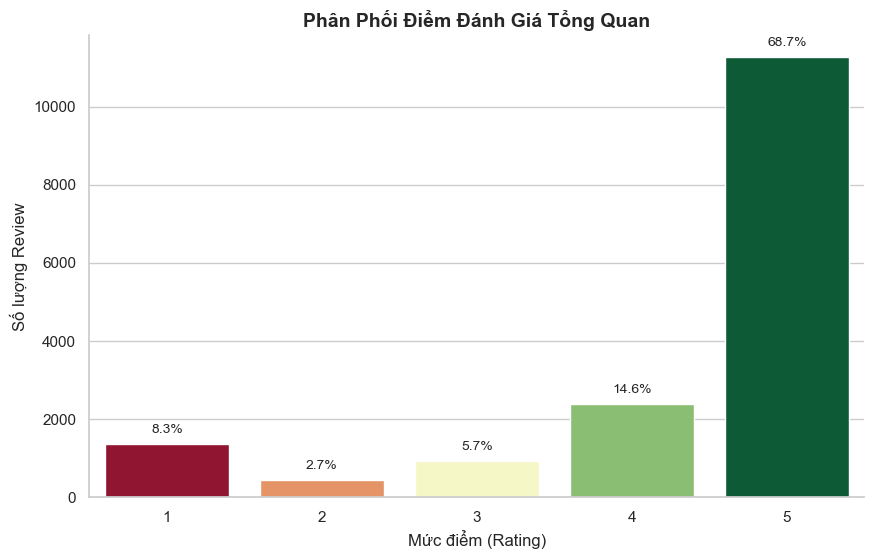

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Vẽ biểu đồ đếm số lượng cho từng mức rating (1, 2, 3, 4, 5)
ax = sns.countplot(data=df_reviews, x='rating', palette='RdYlGn', hue='rating', legend=False)

# Thêm số lượng và % trên đầu cột để dễ quan sát độ mất cân bằng
total = len(df_reviews)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.title('Phân Phối Điểm Đánh Giá Tổng Quan', fontsize=14, fontweight='bold')
plt.xlabel('Mức điểm (Rating)', fontsize=12)
plt.ylabel('Số lượng Review', fontsize=12)
sns.despine()
plt.show()


### **Nhận xét & Insight: Phân phối Điểm đánh giá**

*   **Nhận xét (Observation):**
    *   **Thống trị bởi 5 sao:** Có tới **68.7%** tổng số review là 5 sao, cho thấy mức độ hài lòng tổng quan của khách hàng là rất cao.
    *   **Phân phối hình chữ J:** Dữ liệu tập trung cực mạnh ở hai đầu cực đoan: 5 sao (Rất hài lòng) và 1 sao (Bức xúc - chiếm 8.3%), trong khi các mức điểm trung gian (2-3-4 sao) chiếm tỷ trọng thấp.

*   **Insight tìm kiếm:**
    *   **Tâm lý người dùng:** Khách hàng có xu hướng chủ động đánh giá khi có trải nghiệm **vượt mong đợi** hoặc **quá tệ**. Các trải nghiệm "bình thường" ít khi được ghi nhận.
    *   **Tín hiệu cho mô hình ML:** Dữ liệu bị **mất cân bằng nghiêm trọng (Class Imbalance)**. Nếu dùng để huấn luyện AI phân loại cảm xúc, cần áp dụng các kỹ thuật cân bằng dữ liệu (Oversampling/Undersampling) để tránh mô hình bị thiên kiến (bias) về lớp 5 sao.


## Phân tích Các khía cạnh (Aspect Ratings)

--- ĐIỂM TRUNG BÌNH CÁC KHÍA CẠNH ---
food_rating          4.474466
service_rating       4.420313
atmosphere_rating    4.386458
dtype: Float64


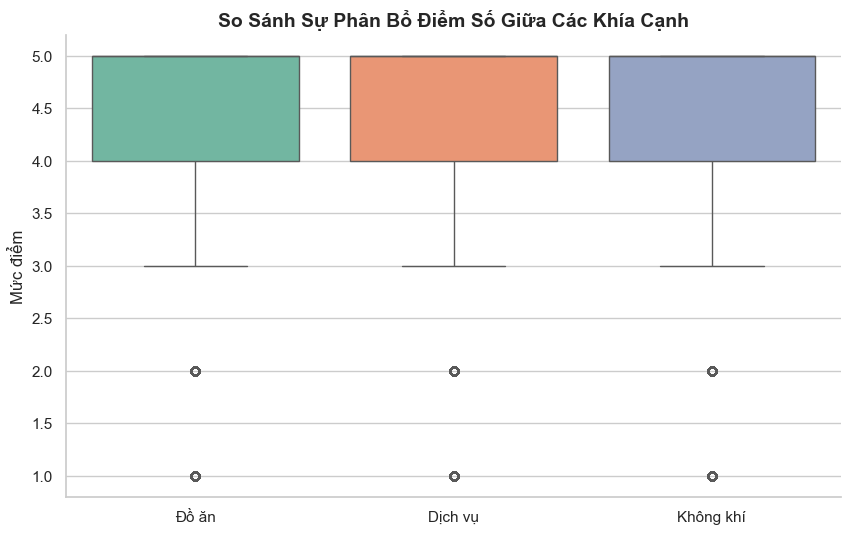

In [88]:
# Chuẩn bị dữ liệu: Lấy các cột khía cạnh và loại bỏ giá trị thiếu (nếu có)
aspects = ['food_rating', 'service_rating', 'atmosphere_rating']
df_aspects = df_reviews[aspects].dropna()

# 1. Tính điểm trung bình
mean_aspects = df_aspects.mean().sort_values(ascending=False)
print("--- ĐIỂM TRUNG BÌNH CÁC KHÍA CẠNH ---")
print(mean_aspects)

# 2. Vẽ Boxplot để so sánh sự phân bổ
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_aspects, palette='Set2')
plt.title('So Sánh Sự Phân Bổ Điểm Số Giữa Các Khía Cạnh', fontsize=14, fontweight='bold')
plt.ylabel('Mức điểm', fontsize=12)
plt.xticks([0, 1, 2], ['Đồ ăn', 'Dịch vụ', 'Không khí'])
sns.despine()
plt.show()


### **Nhận xét & Insight: So sánh các khía cạnh**

*   **Nhận xét (Observation):**
    *   **Đồ ăn (Food) đứng đầu:** Điểm trung bình của Đồ ăn cao nhất (**4.47**), tiếp theo là Dịch vụ (**4.42**) và cuối cùng là Không khí (**4.39**).
    *   **Phân phối tập trung:** Cả 3 khía cạnh đều có Boxplot nằm ở vùng điểm cao (4.0 - 5.0). Điều này cho thấy phần lớn thực khách hài lòng với chất lượng lõi (sản phẩm và dịch vụ).
    *   **Nhiều giá trị ngoại lai (Outliers):** Cả 3 biểu đồ đều xuất hiện các điểm tích cực thấp (1-2 sao) nằm rời rạc bên dưới, phản ánh những trải nghiệm cá nhân đặc biệt tệ.

*   **Insight tìm kiếm:**
    *   **Sức mạnh lõi:** Chất lượng món ăn là thế mạnh chính của các nhà hàng trong tập dữ liệu này. Khách hàng cảm nhận rõ giá trị nhất ở hương vị sản phẩm.
    *   **Điểm cần cải thiện:** Không khí (Atmosphere) có điểm số thấp nhất và dải phân bổ rộng hơn một chút, cho thấy sự không đồng nhất về không gian hoặc tiếng ồn giữa các nhà hàng đang khiến thực khách chưa thực sự thỏa mãn hoàn toàn.
    *   **Mối liên hệ:** Khoảng cách giữa các mức điểm trung bình là rất nhỏ (~0.05 - 0.08 điểm), chứng tỏ các nhà hàng có sự đầu tư khá đồng đều ở cả 3 mảng, tạo ra trải nghiệm dịch vụ trọn gói (comprehensive service).


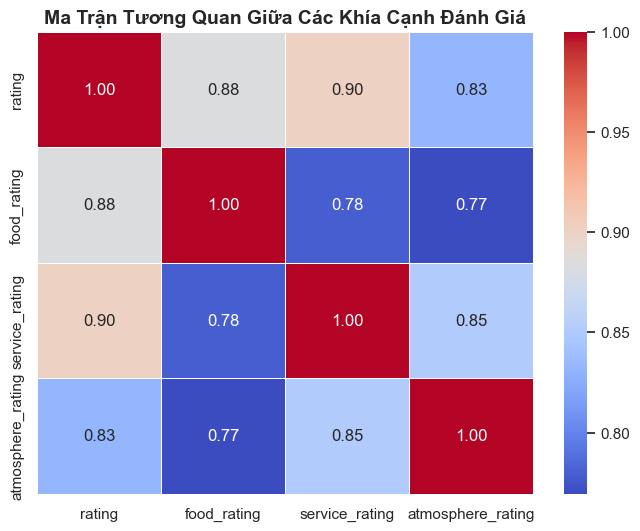

--- PHÂN TÍCH QUYẾT ĐỊNH ---
- Khía cạnh ảnh hưởng mạnh nhất đến Điểm tổng là: service_rating (R = 0.90)
- Nếu service_rating cao, khách có xu hướng chấm Rating tổng cao và ngược lại.


In [89]:
# Tính ma trận tương quan (Correlation Matrix)
corr_matrix = df_reviews[['rating', 'food_rating', 'service_rating', 'atmosphere_rating']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Ma Trận Tương Quan Giữa Các Khía Cạnh Đánh Giá', fontsize=14, fontweight='bold')
plt.show()

# Phân tích nhanh
high_corr_aspect = corr_matrix['rating'].drop('rating').idxmax()
high_corr_val = corr_matrix['rating'][high_corr_aspect]

print(f"--- PHÂN TÍCH QUYẾT ĐỊNH ---")
print(f"- Khía cạnh ảnh hưởng mạnh nhất đến Điểm tổng là: {high_corr_aspect} (R = {high_corr_val:.2f})")
print(f"- Nếu {high_corr_aspect} cao, khách có xu hướng chấm Rating tổng cao và ngược lại.")


### **Nhận xét & Insight: Ma trận tương quan (Correlation Analysis)**

*   **Nhận xét (Observation):**
    *   **Tương quan rất mạnh:** Tất cả các chỉ số đều có hệ số tương quan dương rất cao với điểm tổng (`rating`), dao động từ **0.83 đến 0.90**.
    *   **Dịch vụ (Service) đứng đầu:** Cột `service_rating` có tương quan cao nhất với điểm tổng (**0.90**), kế đến là Đồ ăn (**0.88**) và thấp nhất là Không khí (**0.83**).

*   **Insight tìm kiếm:**
    *   **Yếu tố quyết định:** Dịch vụ là yếu tố quan trọng nhất. Thái độ phục vụ của nhân viên có sức ảnh hưởng trực tiếp và mạnh mẽ nhất đến quyết định chấm điểm cuối cùng của khách hàng.
    *   **Sự cộng hưởng:** Các khía cạnh có tương quan khá cao với nhau (ví dụ: Service & Atmosphere đạt 0.85). Điều này cho thấy nếu một nhà hàng làm tốt dịch vụ, họ thường có xu hướng chỉn chu cả về không gian và đồ ăn.
    *   **Trọng tâm cải thiện:** Để tối ưu hóa điểm số tổng (Rating), các nhà hàng nên ưu tiên tập trung đào tạo đội ngũ dịch vụ, vì đây là "kênh" tác động trực tiếp nhất đến mức độ hài lòng của thực khách.


--- THỐNG KÊ ĐỘ DÀI ---
- Review dài nhất: 928 từ.
- Số lượng review > 256 từ: 238.


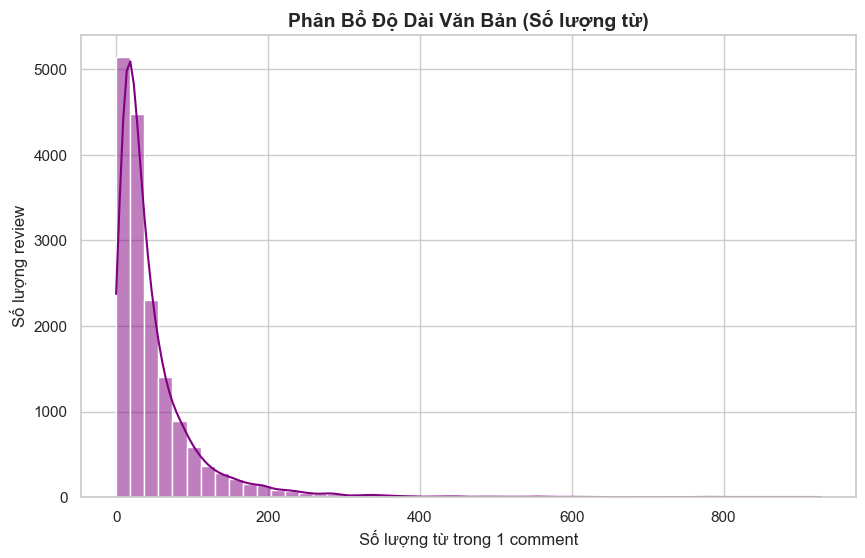

In [90]:
# Tạo cột đếm số từ (word count) - tách bằng khoảng trắng
df_reviews['word_count'] = df_reviews['comment'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['word_count'], bins=50, kde=True, color='purple')
plt.title('Phân Bổ Độ Dài Văn Bản (Số lượng từ)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ trong 1 comment')
plt.ylabel('Số lượng review')

# Tính toán ngưỡng cắt câu cho các mô hình Transformer (PhoBERT)
max_len = df_reviews['word_count'].max()
over_256 = len(df_reviews[df_reviews['word_count'] > 256])

print(f"--- THỐNG KÊ ĐỘ DÀI ---")
print(f"- Review dài nhất: {max_len} từ.")
print(f"- Số lượng review > 256 từ: {over_256}.")
plt.show()


--- THÔNG KÊ SAU KHI LỌC ---
- Đã xóa: 238 review quá dài.
- Còn lại: 16153 review.
- Review dài nhất hiện tại: 256 từ.


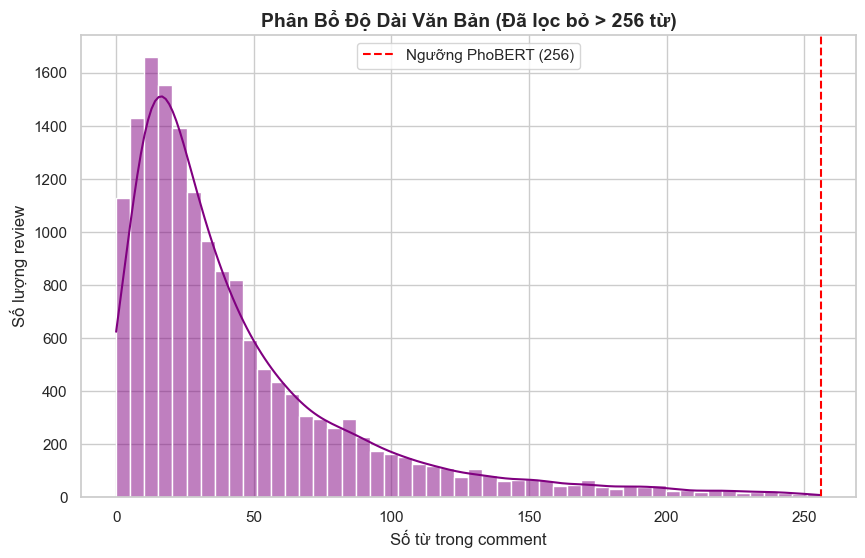

In [91]:
# 1. Tính toán cột word_count để lọc
df_reviews['word_count'] = df_reviews['comment'].apply(lambda x: len(str(x).split()))

# 2. Thực hiện lọc bỏ những dòng > 256 từ
initial_count = len(df_reviews)
df_reviews = df_reviews[df_reviews['word_count'] <= 256].reset_index(drop=True)

# 3. Tính toán lại báo cáo sau khi lọc
final_count = len(df_reviews)
removed_count = initial_count - final_count
max_len_after = df_reviews['word_count'].max()

# 4. Trực quan hóa kết quả sau lọc
plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['word_count'], bins=50, kde=True, color='purple')
plt.axvline(x=256, color='red', linestyle='--', label='Ngưỡng PhoBERT (256)')
plt.title('Phân Bổ Độ Dài Văn Bản (Đã lọc bỏ > 256 từ)', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong comment')
plt.ylabel('Số lượng review')
plt.legend()

print(f"--- THÔNG KÊ SAU KHI LỌC ---")
print(f"- Đã xóa: {removed_count} review quá dài.")
print(f"- Còn lại: {final_count} review.")
print(f"- Review dài nhất hiện tại: {max_len_after} từ.")
plt.show()


In [92]:
import re
import pandas as pd
import unicodedata # Thư viện để chuẩn hóa Unicode

# Tạo các thùng chứa (Log) để lưu kết quả truy vết cho từng lỗi
fixed_encoding = []
fixed_invisible = []
fixed_whitespace = []
fixed_non_alpha = [] # Thùng chứa lưu dấu vết xóa chữ số và mọi dấu câu/ký tự đặc biệt

def track_and_clean(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
        
    step_0 = text
    
    # --- BƯỚC 0.5: Chuẩn hóa Unicode (Sửa lỗi cho chữ "lẩu", "lỗ", v.v.) ---
    # Chuyển đổi Unicode tổ hợp (NFD) thành Unicode dựng sẵn (NFC)
    step_0 = unicodedata.normalize('NFC', step_0)
    
    # --- BƯỚC 1: Sửa lỗi mã hóa (Mojibake) ---
    step_1 = step_0
    try:
        decoded = step_0.encode('latin1').decode('utf-8')
        if decoded != step_0: 
            step_1 = decoded
            fixed_encoding.append({"old": step_0, "new": step_1})
    except:
        pass
        
    # --- BƯỚC 2: Loại bỏ ký tự ẩn (Invisible Characters / Zero-width span) ---
    step_2 = re.sub(r'[\u200b\u200c\u200d\u200e\u200f\ufeff]+', '', step_1)
    step_2 = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', step_2)
    
    if step_2 != step_1:
        fixed_invisible.append({"old": repr(step_1), "new": repr(step_2)})
        
    # --- BƯỚC 3: Xử lý khoảng trắng lộn xộn & Diệt Dấu xuống dòng ---
    step_3 = re.sub(r'[\r\n\t]+', ' ', step_2) 
    step_3 = re.sub(r'\s+', ' ', step_3).strip() 
    
    if step_3 != step_2:
        fixed_whitespace.append({"old": repr(step_2), "new": repr(step_3)})

    # --- BƯỚC 4: Chuyển toàn bộ về chữ thường ---
    step_4 = step_3.lower()

    # --- BƯỚC 5: XÓA SẠCH MỌI THỨ KHÔNG PHẢI LÀ CHỮ CÁI (Chỉ giữ chữ cái và khoảng trắng) ---
    # [^\w\s] -> Xóa mọi dấu câu, ngoặc kép, ký tự đặc biệt (như : , . - “ ” ! ?)
    # _ -> Xóa dấu gạch dưới
    # \d -> Xóa chữ số
    step_5 = re.sub(r'[^\w\s]|_|\d', ' ', step_4)
    
    # Dọn dẹp lại khoảng trắng lộn xộn (do vị trí các dấu bị xóa tạo thành khoảng trắng thừa)
    step_5 = re.sub(r'\s+', ' ', step_5).strip()
    
    if step_5 != step_4:
        fixed_non_alpha.append({"old": step_4, "new": step_5})
        
    return step_5

# Khởi chạy Bot Dọn Dẹp
print(f"Đang quét dọn {len(df_reviews)} bình luận. Vui lòng chờ...")
initial_count = len(df_reviews)

# Cập nhật cột comment
df_reviews['comment'] = df_reviews['comment'].apply(track_and_clean)

# --- Xóa đánh giá rỗng (Chuỗi rỗng "" hoặc chỉ còn toàn dấu câu đã bị xóa trắng) ---
df_reviews = df_reviews[df_reviews['comment'] != ''].reset_index(drop=True)
empty_removed_count = initial_count - len(df_reviews)


# ==========================================
# IN RA MINH CHỨNG (SHOW LOG)
# ==========================================

print("\n" + "="*80)
print(f"[BƯỚC 1] LUẬT ENCODING: Lôi ra ánh sáng {len(fixed_encoding)} review lỗi Font chữ")

print("\n" + "="*80)
print(f"[BƯỚC 2] KÝ TỰ TÀNG HÌNH: Đã bóc mẽ {len(fixed_invisible)} review")

print("\n" + "="*80)
print(f"[BƯỚC 3] KHOẢNG TRẮNG / XUỐNG DÒNG: Đã là phẳng {len(fixed_whitespace)} review bị ngắt dòng")

print("\n" + "="*80)
print(f"[BƯỚC 4 & 5] DỌN SẠCH DẤU CÂU & CHỮ SỐ: Đã chuẩn hóa {len(fixed_non_alpha)} review")
for i, item in enumerate(fixed_non_alpha[:5]): # In ra 5 ví dụ
    print(f"❌ [Gốc]:  {item['old']}")
    print(f"✅ [Mới]:  {item['new']}\n")

print("\n" + "="*80)
print(f"[BƯỚC CHUNG] DỮ LIỆU RỖNG: Đã phát hiện và xóa {empty_removed_count} review trống")
print(f"-> Tổng số review còn lại sau khi dọn dẹp: {len(df_reviews)}\n")

Đang quét dọn 16153 bình luận. Vui lòng chờ...

[BƯỚC 1] LUẬT ENCODING: Lôi ra ánh sáng 0 review lỗi Font chữ

[BƯỚC 2] KÝ TỰ TÀNG HÌNH: Đã bóc mẽ 44 review

[BƯỚC 3] KHOẢNG TRẮNG / XUỐNG DÒNG: Đã là phẳng 4940 review bị ngắt dòng

[BƯỚC 4 & 5] DỌN SẠCH DẤU CÂU & CHỮ SỐ: Đã chuẩn hóa 14638 review
❌ [Gốc]:  trước khi đến quán đã xem thực đơn và thấy giá cao, tuy nhiên vẫn đến để trải nghiệm vì expect với mức giá này thì thịt chắc là loại ngon đặc biệt, nhưng thực tế khá thất vọng vì thấy chất lượng thịt cũng bình thường, mình đi 3ng, ăn sương sương hết gần 1 củ mà chẳng thấm tháp vào đâu, chắc là ăn panchan cho no, panchan hành muối chua ăn khá ngon. bò 400k được 5 lát mỏng =))
✅ [Mới]:  trước khi đến quán đã xem thực đơn và thấy giá cao tuy nhiên vẫn đến để trải nghiệm vì expect với mức giá này thì thịt chắc là loại ngon đặc biệt nhưng thực tế khá thất vọng vì thấy chất lượng thịt cũng bình thường mình đi ng ăn sương sương hết gần củ mà chẳng thấm tháp vào đâu chắc là ăn panchan cho no

## Chuẩn hóa emoji trong review

In [93]:
# Cài thư viện nếu chưa có
!pip install emoji -q

In [94]:
import pandas as pd
import emoji
from collections import Counter

# Không cần đọc lại file nữa, cấu hình lại cột comment:
COMMENT_COL = "comment"

# In ra độ lớn của DataFrame hiện tại
print(f"Bắt đầu phân tích trên {len(df_reviews):,} dòng review")

def extract_emojis(text):
    """Trả về danh sách emoji xuất hiện trong chuỗi (kể trùng)."""
    if not isinstance(text, str):
        return []
    return [e["emoji"] for e in emoji.emoji_list(text)]

# Tạo các cột nháp (sẽ xóa đi sau)
df_reviews["emojis_found"]         = df_reviews[COMMENT_COL].apply(extract_emojis)
df_reviews["emoji_count"]          = df_reviews["emojis_found"].apply(len)
df_reviews["unique_emoji_in_review"] = df_reviews["emojis_found"].apply(lambda x: len(set(x)))
df_reviews["has_emoji"]            = df_reviews["emoji_count"] > 0


total_rows              = len(df_reviews)
reviews_with_emoji      = df_reviews["has_emoji"].sum()
all_emojis              = [e for lst in df_reviews["emojis_found"] for e in lst]
total_emoji_occurrences = len(all_emojis)
unique_emoji_types      = len(set(all_emojis))

summary = pd.DataFrame({
    "Chỉ số": [
        "Tổng số dòng review",
        "Review có chứa emoji",
        "Tỷ lệ review có emoji",
        "Tổng lượt emoji xuất hiện",
        "Số LOẠI emoji khác nhau",
        "Review nhiều emoji nhất",
    ],
    "Giá trị": [
        f"{total_rows:,}",
        f"{reviews_with_emoji:,}",
        f"{reviews_with_emoji / total_rows * 100:.1f}%",
        f"{total_emoji_occurrences:,}",
        f"{unique_emoji_types:,}",
        f"{df_reviews['emoji_count'].max()}",
    ]
})

display(summary)

Bắt đầu phân tích trên 15,548 dòng review


,Chỉ số,Giá trị
0,Tổng số dòng review,"15,548"
1,Review có chứa emoji,0
2,Tỷ lệ review có emoji,0.0%
3,Tổng lượt emoji xuất hiện,0
4,Số LOẠI emoji khác nhau,0
5,Review nhiều emoji nhất,0


In [95]:
# Tạo Counter cho toàn bộ danh sách emoji
emoji_counter = Counter(all_emojis)

emoji_df = pd.DataFrame([
    {
        "emoji":            e,
        "ten_emoji":        emoji.demojize(e, language="en").strip(":").replace("_", " "),
        "so_lan_xuat_hien": cnt,
        "phan_tram":        round(cnt / total_emoji_occurrences * 100, 2) if total_emoji_occurrences else 0,
        "so_review_chua":   sum(1 for lst in df_reviews["emojis_found"] if e in lst),
    }
    for e, cnt in emoji_counter.most_common()
])

print(f"Tổng số loại emoji: {len(emoji_df)}")
display(emoji_df.head(10)) # In thử top 10

# Đường dẫn lưu bảng phân tích, lưu trên preprocessed nhé
# OUTPUT_PATH = r"../dataset/preprocessed/emoji_analysis_results.csv"

# emoji_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
# print(f"✅ Đã lưu kết quả phân tích Emoji → {OUTPUT_PATH}")

Tổng số loại emoji: 0


""


In [96]:
import emoji
import re

# 1. Từ điển cảm xúc quan trọng
emotion_mapping = {
    # Nhóm Yêu thích / Tim (Heart)
    '❤': ' yêu_thích ', '❤️': ' yêu_thích ', '💚': ' yêu_thích ', '🤍': ' yêu_thích ', 
    '💕': ' yêu_thích ', '💖': ' yêu_thích ', '💗': ' yêu_thích ', '💓': ' yêu_thích ', 
    '🩷': ' yêu_thích ', '💛': ' yêu_thích ', '🩵': ' yêu_thích ', '🤎': ' yêu_thích ', 
    '♥️': ' yêu_thích ', '❣️': ' yêu_thích ', '💞': ' yêu_thích ', '💘': ' yêu_thích ',
    '🫶': ' thả_tim ', '🫶🏻': ' thả_tim ', '🫶🏼': ' thả_tim ', '🫶🏿': ' thả_tim ',

    # Nhóm Khen ngợi / Tuyệt vời / Đánh giá cao
    '😍': ' tuyệt_vời ', '🥰': ' đáng_yêu ', '🤩': ' xuất_sắc ',
    '👍': ' tốt ', '👍🏻': ' tốt ', '👍🏼': ' tốt ', 
    '👌': ' đồng_ý ', '👌🏻': ' đồng_ý ', '👌🏼': ' đồng_ý ',
    '👏': ' tán_thưởng ', '👏🏻': ' tán_thưởng ', '👏🏼': ' tán_thưởng ',
    '💯': ' hoàn_hảo ', '⭐': ' sao_đánh_giá ', '🌟': ' sao_tuyệt_vời ', 
    '✨': ' lấp_lánh ', '🔥': ' cực_đỉnh ', '✅': ' tốt ', '✔️': ' tốt ',

    # Nhóm Vui vẻ / Hài lòng
    '😊': ' vui_vẻ ', '😁': ' vui_vẻ ', '😃': ' thích_thú ', '😄': ' vui_vẻ ', 
    '😀': ' vui_vẻ ', '🙂': ' hài_lòng ', '☺️': ' hài_lòng ', '😆': ' cười_lớn ',
    '😂': ' buồn_cười ', '🤣': ' buồn_cười ', '🤭': ' cười_tủm_tỉm ',
    '😅': ' cười_ngại ', '😉': ' nháy_mắt ', '😜': ' vui_nhộn ', '🤪': ' vui_nhộn ',
    '😘': ' hôn_gió ', '😚': ' hôn_gió ', '😙': ' hôn_gió ', '😗': ' hôn_gió ',
    '😌': ' nhẹ_nhõm ', '😇': ' ngoan_ngoãn ',

    # Nhóm Khen món ăn ngon
    '😋': ' ngon_miệng ', '🤤': ' thèm_thuồng ',

    # Nhóm Cảm động / Rưng rưng
    '🥲': ' cảm_động ', '🥹': ' rưng_rưng ', '🥺': ' mong_chờ ',

    # Nhóm Chê bai / Tệ / Tức giận
    '👎': ' tệ ', '👎🏻': ' tệ ', 
    '😡': ' tức_giận ', '🤬': ' chửi_rủa ', '😤': ' bực_bội ', '😠': ' bực_mình ',
    '😑': ' chán_nản ', '😒': ' không_hài_lòng ', '🙄': ' chán_ngán ', '😐': ' bình_thường ',
    '❌': ' không_tốt ', '⚠️': ' cảnh_báo ',

    # Nhóm Buồn / Khóc
    '😭': ' khóc_lớn ', '😢': ' buồn_khóc ', '😞': ' thất_vọng ', '😔': ' chán_nản ',
    '😓': ' mệt_mỏi ', '😥': ' buồn_bực ', '😫': ' mệt_mỏi ', '😣': ' khó_chịu ',

    # Nhóm Sợ hãi / Bất ngờ / Ghê tởm
    '🤢': ' buồn_nôn ', '🤮': ' kinh_tởm ', '🤯': ' bất_ngờ ', '😱': ' hoảng_hốt ',
    '😳': ' bối_rối ', '😨': ' sợ_hãi '
}

def filter_and_convert_emojis(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Bước 1: Dịch các emoji cảm xúc
    for emj, text_replacement in emotion_mapping.items():
        if emj in text:
            text = text.replace(emj, text_replacement)
            
    # Bước 2: XÓA SẠCH toàn bộ các emoji phần dư (không phải cảm xúc) còn sót lại 
    text = emoji.replace_emoji(text, replace='')
    
    # Bước 3: Dọn dẹp khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Chạy tiền xử lý trên cột comment_cleaned
print("Đang giữ lại emoji cảm xúc và xóa các emoji nhiễu. Vui lòng chờ...")
df_reviews['comment_cleaned'] = df_reviews['comment'].apply(filter_and_convert_emojis)

# Xem thử kết quả (khi chưa xóa cột tạm)
print("--- KẾT QUẢ SO SÁNH (REVIEW TỪNG CÓ EMOJI) ---")
display(df_reviews[df_reviews['has_emoji']].head(10)[['comment', 'comment_cleaned']])

# Cuối cùng: Gán đè kết quả về lại cột comment_cleaned và xóa sạch các cột tạm sinh ra lúc nãy
df_reviews['comment'] = df_reviews['comment_cleaned']
cols_to_drop = ['emojis_found', 'emoji_count', 'unique_emoji_in_review', 'has_emoji', 'comment_cleaned']
df_reviews = df_reviews.drop(columns=cols_to_drop)

print("\nĐã làm sạch xong. Bảng df_reviews giờ đã gỡ bỏ hoàn toàn emoji rác.")

Đang giữ lại emoji cảm xúc và xóa các emoji nhiễu. Vui lòng chờ...
--- KẾT QUẢ SO SÁNH (REVIEW TỪNG CÓ EMOJI) ---


,comment,comment_cleaned



Đã làm sạch xong. Bảng df_reviews giờ đã gỡ bỏ hoàn toàn emoji rác.


In [97]:
import emoji

# Hàm kiểm tra xem chuỗi có chứa bất kỳ emoji nào không
def contains_emoji(text):
    if pd.isna(text) or not isinstance(text, str):
        return False
    # Nếu danh sách emoji trả về có phần tử -> có emoji
    return len(emoji.emoji_list(text)) > 0

# Lọc ra các dòng vẫn còn dính emoji
remaining_emojis_df = df_reviews[df_reviews['comment'].apply(contains_emoji)]

# Kiểm tra và in kết quả
if len(remaining_emojis_df) == 0:
    print("Tuyệt vời! Không còn bất kỳ emoji nào sót lại trong cột 'comment'. Dữ liệu đã sạch hoàn toàn.")
else:
    print(f"CẢNH BÁO: Vẫn còn {len(remaining_emojis_df)} review dính emoji chưa được xử lý hết!")
    print("Dưới đây là một số mẫu bị sót để bạn kiểm tra:")
    display(remaining_emojis_df[['comment']].head(10))

Tuyệt vời! Không còn bất kỳ emoji nào sót lại trong cột 'comment'. Dữ liệu đã sạch hoàn toàn.


## Xử lý teencode (Kéo dài từ)

In [98]:
import re
import pandas as pd

def remove_elongation(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Chuyển \1+ thành \1{2,} 
    # Nghĩa là: Giữ lại 1 ký tự gốc + Nếu nó lặp lại thêm 2 lần trở lên (tổng >= 3 lần) thì mới cắt bỏ
    pattern = r'([a-zđáàãảạâấầẫẩậăắằẵẳặéèẽẻẹêếềễểệíìĩỉịóòõỏọôốồỗổộơớờỡởợúùũủụưứừữửựýỳỹỷỵ])\1{2,}'
    
    # Thay thế những cụm >= 3 ký tự về đúng 1 ký tự
    return re.sub(pattern, r'\1', text, flags=re.IGNORECASE)

# Lưu cột gốc để đếm số dòng thay đổi
df_reviews['comment_old'] = df_reviews['comment']

print("Đang dọn dẹp các ký tự bị kéo dài (VD: ngonnnn -> ngon)...")
# Áp dụng chuẩn hóa
df_reviews['comment'] = df_reviews['comment'].apply(remove_elongation)

# Thống kê kết quả
changed_rows = (df_reviews['comment'] != df_reviews['comment_old']).sum()
print(f"Đã xử lý xong!")
print(f"Tổng số bình luận chứa lỗi kéo dài ký tự đã được sửa: {changed_rows} dòng")

# Xóa cột tạm
df_reviews = df_reviews.drop(columns=['comment_old'])

# Xem thử kết quả
display(df_reviews[['comment']].head(10))

Đang dọn dẹp các ký tự bị kéo dài (VD: ngonnnn -> ngon)...
Đã xử lý xong!
Tổng số bình luận chứa lỗi kéo dài ký tự đã được sửa: 454 dòng


,comment
0,trước khi đến quán đã xem thực đơn và thấy giá...
1,nướng hàn ngon nha mng ăn cũng ok không gian c...
2,lần đầu tiên tới quán mẹ mình khá khó tính cũn...
3,món ăn ngon có món da heo nướng đặc biệt không...
4,đồ ăn tươi và ngon đặc biệt là da heo nướng pa...
5,đáng để trải nghiệm panchan nhiều và được fill...
6,thịt cũng ngon nhưng không phải xuất sắc phục ...
7,cũng được sẽ có nhiều sự lựa chọn tốt hơn tron...
8,nhân viên dễ thương nhiệt tình hỗ trợ tư vấn k...
9,quán ăn ngon món lòng đúng là ngon hết xảy thị...


## Chuẩn hóa Teencode, Viết tắt

In [99]:
import pandas as pd
import re
import os

# ============================================================
# BƯỚC 1: TỪ ĐIỂN VIẾT TẮT / TEENCODE THỦ CÔNG
# ============================================================
# ============================================================
# BƯỚC 1: TỪ ĐIỂN VIẾT TẮT / TEENCODE / TIẾNG ANH (CẬP NHẬT)
# ============================================================
ABBREV_DICT = {
    # 1. TỪ PHỦ ĐỊNH / TỪ NỐI / TRẠNG TỪ
    "ko": "không", "k": "không", "kh": "không", "kg": "không", "kog": "không", 
    "khg": "không", "hong": "không", "hok": "không", "khom": "không", "khong": "không",
    "vs": "với", "cx": "cũng", "cg": "cũng", "cũg": "cũng", "cux": "cũng", 
    "trc": "trước", "truoc": "trước", "th": "thì",
    "lun": "luôn", "luon": "luôn", "luonn": "luôn", "luônn": "luôn",
    "r": "rồi", "rùi": "rồi", "rui": "rồi", "ròi": "rồi", "xog": "xong",
    "z": "vậy", "vz": "vậy", "zậy": "vậy", "zui": "vui", "dzui": "vui",
    "j": "gì", "qá": "quá", "qa": "quá", "quáa": "quá", "rât": "rất",
    "nhma": "nhưng mà", "nma": "nhưng mà", "nhg": "nhưng",
    "nchung": "nói chung", "nc": "nói chung", "nch": "nói chung",
    "bt": "bình thường", "bth": "bình thường", "bthg": "bình thường", "bthuong": "bình thường",
    "vc": "vô cùng", "vcl": "vô cùng", "vl": "vô cùng", "vch": "vô cùng",
    "ntn": "như thế nào", "ms": "mới",

    # 2. NGƯỜI / ĐẠI TỪ
    "nv": "nhân viên", "nvien": "nhân viên", "nvpv": "nhân viên phục vụ",
    "ng": "người", "ngta": "người ta", "ngừoi": "người", "nguoi": "người", "ngươ": "người",
    "mk": "mình", "mik": "mình", "tui": "tôi", "t": "tôi",
    "mn": "mọi người", "mng": "mọi người", "mnguoi": "mọi người",
    "bn": "bạn", "b": "bạn", "ae": "anh em", "ce": "chị em",
    "gd": "gia đình", "gđ": "gia đình", "gdinh": "gia đình",

    # 3. THUẬT NGỮ NHÀ HÀNG / DỊCH VỤ / TRẢI NGHIỆM
    "đc": "được", "dc": "được", "dk": "được", "đk": "được", "đươc": "được",
    "ql": "quản lý", "qly": "quản lý", "cskh": "chăm sóc khách hàng",
    "pv": "phục vụ", "pvu": "phục vụ", "phuc": "phục vụ",
    "kh": "khách hàng", # (tùy ngữ cảnh, có thể là 'không')
    "ch": "cửa hàng", "nh": "nhà hàng", "cn": "chi nhánh",
    "đt": "điện thoại", "dt": "điện thoại",
    "ck": "chuyển khoản", "tt": "thanh toán", "vat": "thuế VAT",
    "km": "khuyến mãi", "sp": "sản phẩm", "cty": "công ty",
    "đb": "đặc biệt", "dbiet": "đặc biệt",
    "kgian": "không gian", "csvc": "cơ sở vật chất",
    "dth": "dễ thương", "dthw": "dễ thương", "dthuong": "dễ thương",
    "mlem": "ngon", "thik": "thích", "thix": "thích",
    "hssv": "học sinh sinh viên", "hs": "học sinh", "sv": "sinh viên",
    "sn": "sinh nhật",
    "thit": "thịt", "nuoc": "nước", "nhiet": "nhiệt", "thuong": "thương",

    # 4. THỜI GIAN / ĐỊA DANH
    "hnay": "hôm nay", "hm": "hôm nay",
    "hqua": "hôm qua", "hqa": "hôm qua",
    "tgian": "thời gian", "tg": "thời gian",
    "hcm": "Hồ Chí Minh", "tphcm": "TP. Hồ Chí Minh",
    "hn": "Hà Nội", "sg": "Sài Gòn", "tp": "thành phố",
    "vn": "Việt Nam", "hq": "Hàn Quốc",
    "pmh": "Phú Mỹ Hưng", "svh": "Sư Vạn Hạnh",

    # 5. SỬA LỖI CHÍNH TẢ / CẢM THÁN KÉO DÀI
    "ok": "ok", "oke": "ok", "okela": "ok", "okila": "ok", "okey": "ok", "oki": "ok",
    "ngonn": "ngon", "lắmm": "lắm",
    "nhaa": "nha", "ạa": "ạ", "ạaa": "ạ", "nhee": "nhé",
    "tr": "trời", "chời": "trời",
    "haha": "haha", "hihi": "hihi", "huhu": "huhu",

    # 6. TIẾNG ANH: VIẾT TẮT / SAI CHÍNH TẢ -> TIẾNG ANH CHUẨN
    "rcm": "recommend", "rec": "recommend", "recomend": "recommend", "reccomend": "recommend",
    "ord": "order", "oder": "order",
    "rv": "review",
    "cmt": "comment", "rep": "reply",
    "fb": "facebook", "ig": "instagram", "ib": "inbox",
    "wf": "wifi", "cf": "cafe",
    "stt": "status", "app": "application",
    "toping": "topping", "toppings": "topping",
    "dishes": "dish", "noodles": "noodle", "prices": "price", "services": "service",
    "takecare": "take care", "chilli": "chili",

    # 7. TIẾNG ANH & NGOẠI LAI (CHUẨN HÓA MỘT SỐ TÊN GỌI)
    "panchan": "banchan", "pancha": "banchan",
    "kimbab": "kimbap",
    "tokbokki": "tokbokki", "tok": "tokbokki", "tteokbokki": "tokbokki", "tobokki": "tokbokki",
    "phomai": "phô mai",
    "vnd": "VNĐ", "vnđ": "VNĐ",
    "nvs": "WC", "wc": "WC",
    "qr": "QR",

    
}

# BƯỚC 2: HÀM NORMALIZE VIẾT TẮT

def normalize_text(text: str) -> str:
    """Thay thế từ viết tắt bằng từ đầy đủ dựa theo ABBREV_DICT."""
    if not isinstance(text, str):
        return ""
        
    words = text.split()
    normalized = []
    for w in words:
        w_lower = w.lower()
        if w_lower in ABBREV_DICT:
            normalized.append(ABBREV_DICT[w_lower])
        else:
            normalized.append(w)
    return " ".join(normalized)

# BƯỚC 3: ÁP DỤNG THAY ĐỔI

# Giả sử bạn đang có dataframe `df_reviews`
# Xóa các dòng comment bị rỗng (NaN)
df_reviews = df_reviews.dropna(subset=['comment']).copy()

# (Tuỳ chọn) Nếu bạn muốn ghi đè trực tiếp lên cột comment cũ, sử dụng lệnh dưới đây:
df_reviews['comment'] = df_reviews['comment'].apply(normalize_text)

print("Đã hoàn thành việc quy đổi từ viết tắt!")

Đã hoàn thành việc quy đổi từ viết tắt!


--- THÔNG KÊ TIỀN XỬ LÝ ---
- Đã xóa: 0 review quá dài.
- Còn lại: 15548 review.
- Review dài nhất hiện tại: 256 từ.


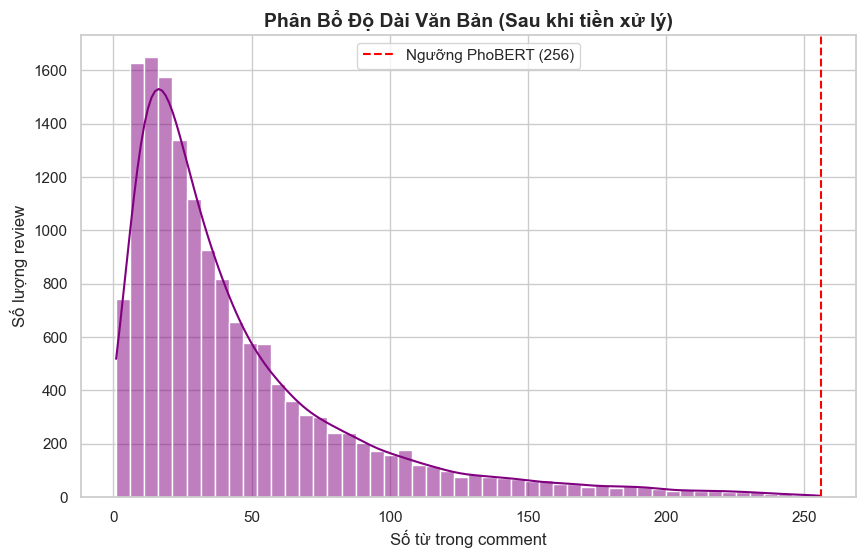

In [100]:
# 1. Tính toán cột word_count để lọc
df_reviews['word_count'] = df_reviews['comment'].apply(lambda x: len(str(x).split()))

# 2. Thực hiện lọc bỏ những dòng > 256 từ
initial_count = len(df_reviews)
df_reviews = df_reviews[df_reviews['word_count'] <= 256].reset_index(drop=True)

# 3. Tính toán lại báo cáo sau khi lọc
final_count = len(df_reviews)
removed_count = initial_count - final_count
max_len_after = df_reviews['word_count'].max()

# 4. Trực quan hóa kết quả sau lọc
plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['word_count'], bins=50, kde=True, color='purple')
plt.axvline(x=256, color='red', linestyle='--', label='Ngưỡng PhoBERT (256)')
plt.title('Phân Bổ Độ Dài Văn Bản (Sau khi tiền xử lý)', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong comment')
plt.ylabel('Số lượng review')
plt.legend()

print(f"--- THÔNG KÊ TIỀN XỬ LÝ ---")
print(f"- Đã xóa: {removed_count} review quá dài.")
print(f"- Còn lại: {final_count} review.")
print(f"- Review dài nhất hiện tại: {max_len_after} từ.")
plt.show()


## 2. Tần suất xuất hiện N-grams (Từ vựng)

Số lượng review 1 sao: 1278
Số lượng review 2 sao: 397
Số lượng review 3 sao: 865
Số lượng review 4 sao: 2272
Số lượng review 5 sao: 10736


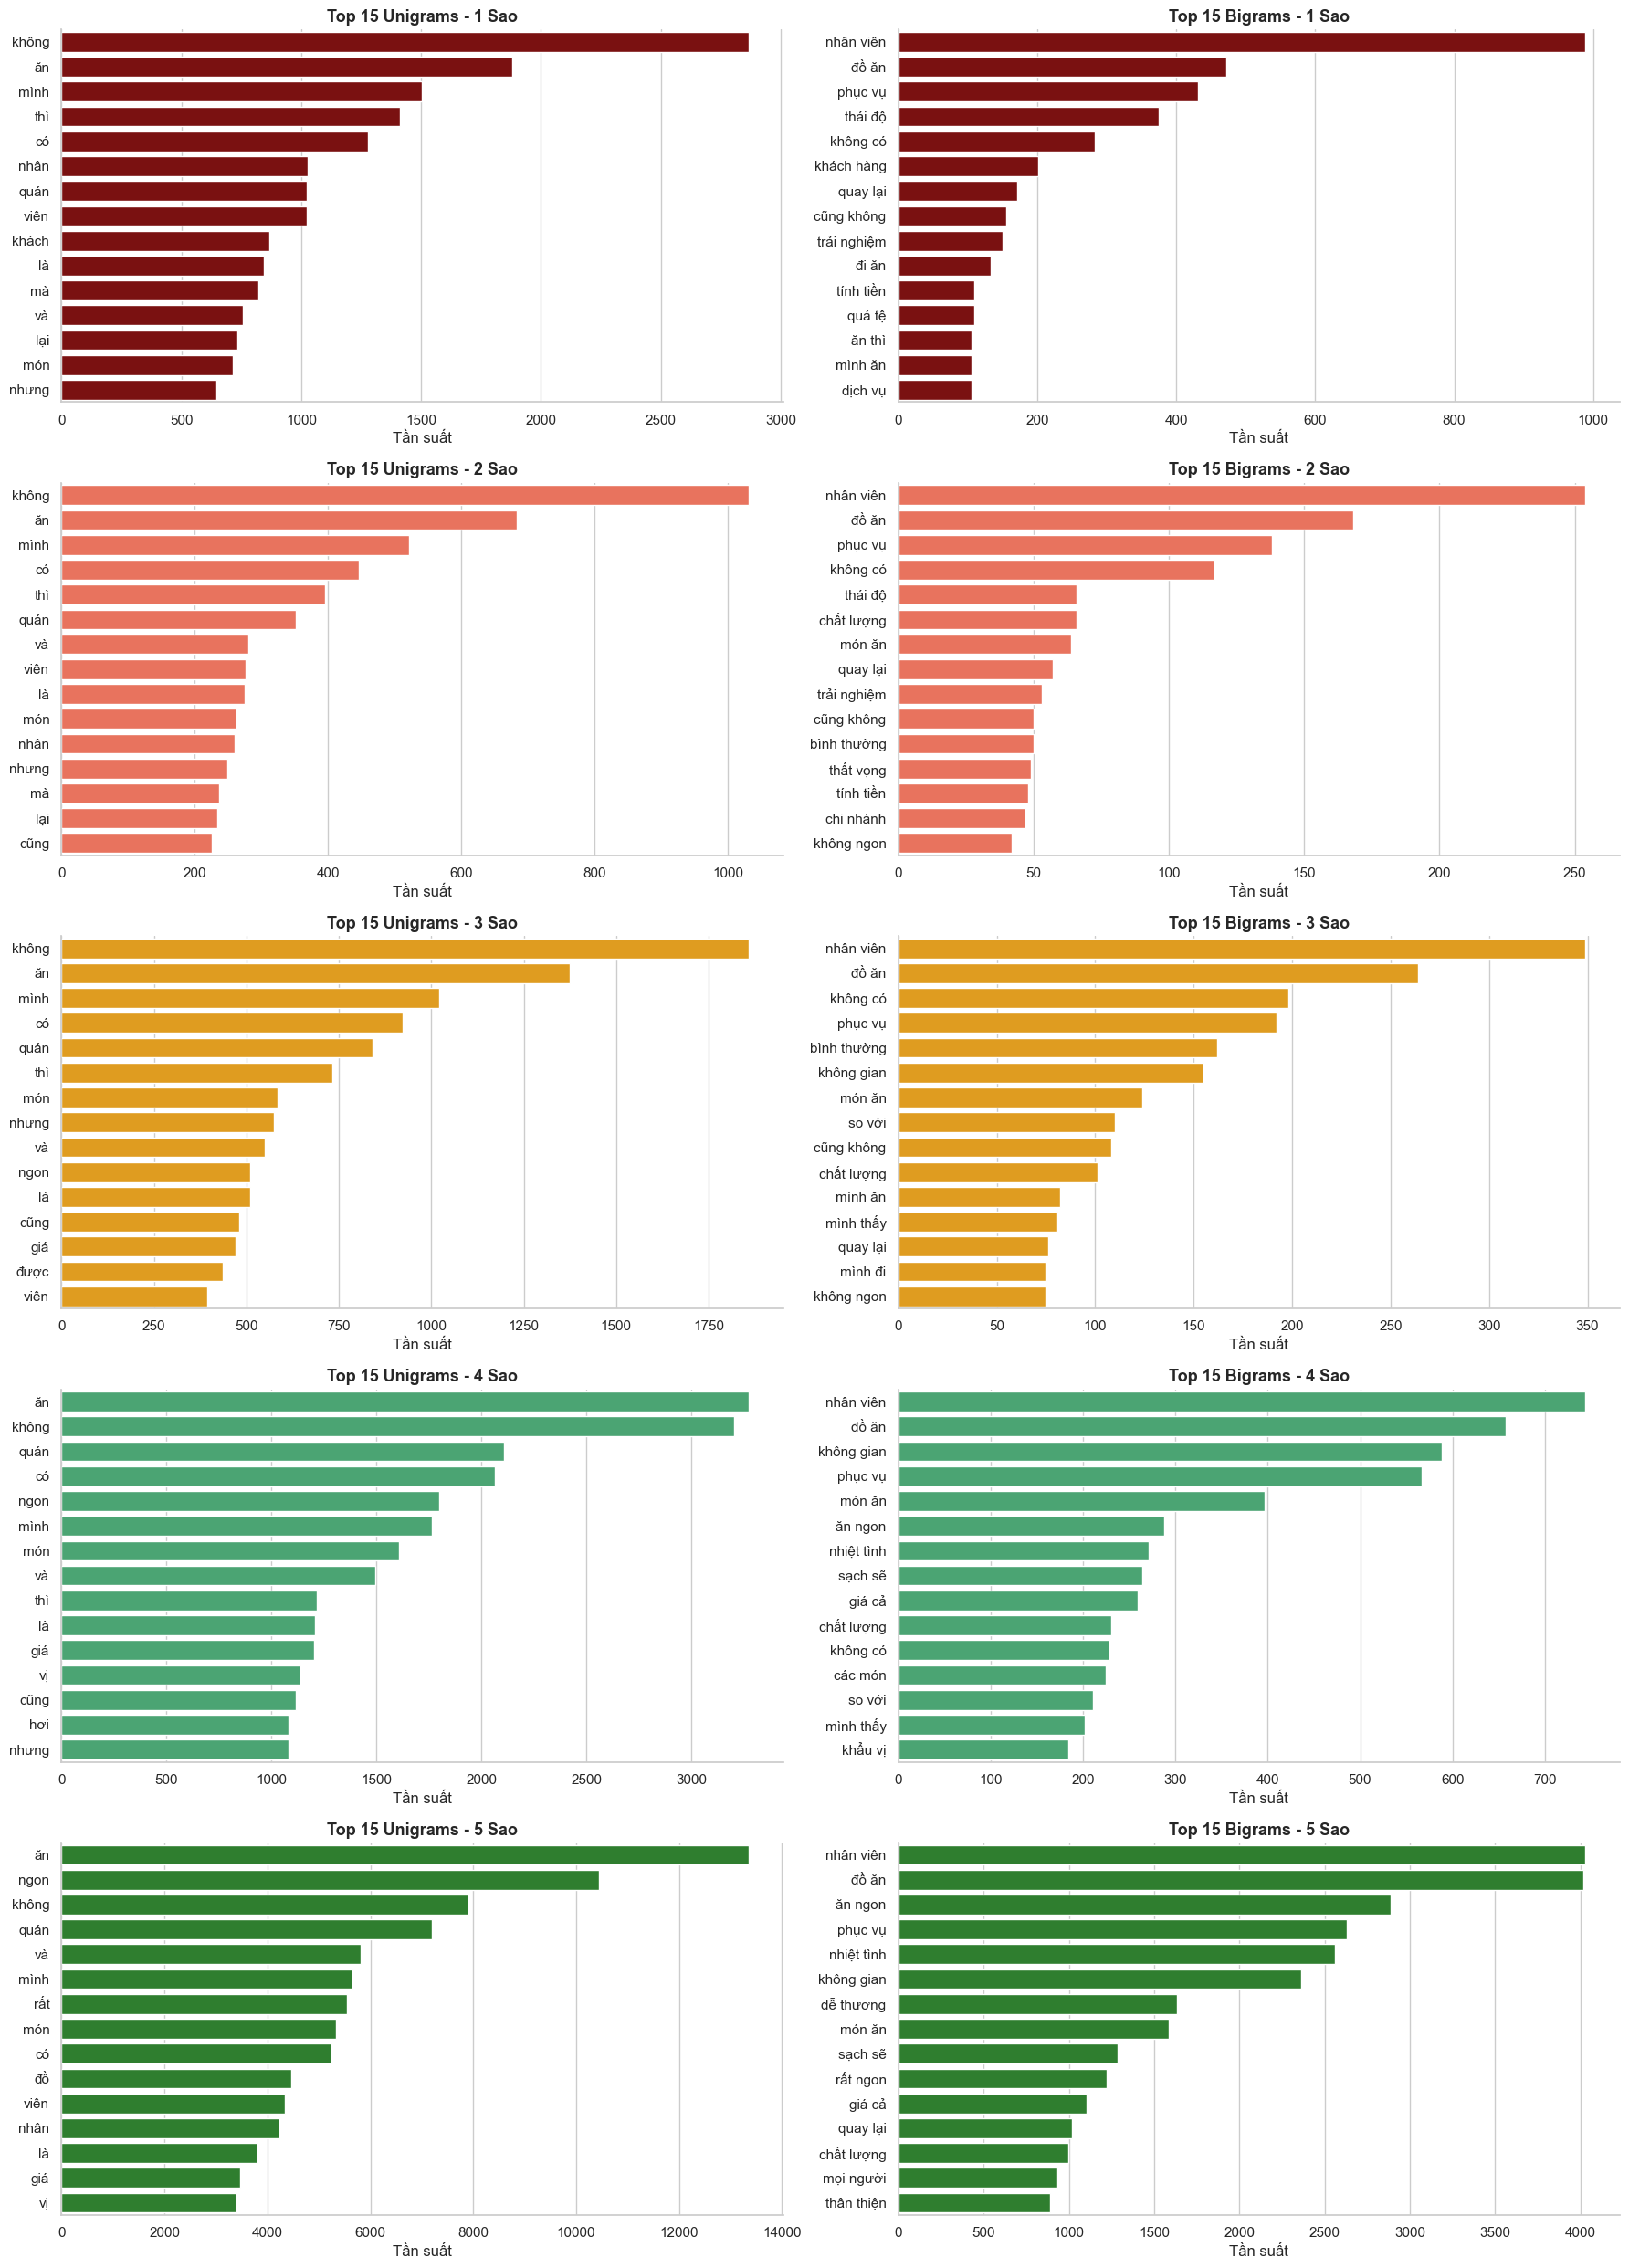

In [101]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Hàm phụ trợ để trích xuất N-gram từ một tập văn bản
def get_top_ngrams(corpus, n=None, ngram_range=(1, 1)):
    if len(corpus) == 0: 
        return []
    
    # Khởi tạo CountVectorizer
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Lấy danh sách từ và tần suất
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Sắp xếp giảm dần theo tần suất
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # Nếu n=None, trả về toàn bộ danh sách
    return words_freq if n is None else words_freq[:n]

# Hàm vẽ biểu đồ (Trực quan hóa)
def plot_ngrams(ax, data, title, color):
    if not data: # Bỏ qua nếu không có dữ liệu
        return
    df_ngrams = pd.DataFrame(data, columns=['N-gram', 'Tần suất'])
    sns.barplot(x='Tần suất', y='N-gram', data=df_ngrams, ax=ax, color=color)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Tần suất')
    ax.set_ylabel('')

# Tạo không gian vẽ 10 biểu đồ (5 hàng x 2 cột)
fig, axes = plt.subplots(5, 2, figsize=(18, 25))

# Dải màu hiển thị từ Tiêu cực (Đỏ) -> Tích cực (Xanh)
colors = ['darkred', 'tomato', 'orange', 'mediumseagreen', 'forestgreen']

# --- THÚNG CHỨA ĐỂ LƯU TOÀN BỘ DỮ LIỆU N-GRAMS ---
all_ngrams_data = []

# Duyệt qua từng mức rating từ 1 đến 5
for i, rating in enumerate(range(1, 6)):
    # Lấy dữ liệu theo rating
    corpus = df_reviews[df_reviews['rating'] == rating]['comment'].dropna()
    print(f"Số lượng review {rating} sao: {len(corpus)}")
    
    # RÚT TRÍCH TOÀN BỘ N-GRAMS (Không đưa giới hạn n vào)
    all_unigrams = get_top_ngrams(corpus, n=None, ngram_range=(1, 1))
    all_bigrams = get_top_ngrams(corpus, n=None, ngram_range=(2, 2))
    
    # Lưu vào danh sách tổng
    for ngram, freq in all_unigrams:
        all_ngrams_data.append({'Rating': rating, 'Loại': 'Unigram', 'N-gram': ngram, 'Tần suất': freq})
        
    for ngram, freq in all_bigrams:
        all_ngrams_data.append({'Rating': rating, 'Loại': 'Bigram', 'N-gram': ngram, 'Tần suất': freq})
    
    # Vẽ biểu đồ cho hàng thứ i (Vẫn chỉ cắt Top 15 để hình vẽ không bị quá tải)
    plot_ngrams(axes[i, 0], all_unigrams[:15], f'Top 15 Unigrams - {rating} Sao', colors[i])
    plot_ngrams(axes[i, 1], all_bigrams[:15],  f'Top 15 Bigrams - {rating} Sao', colors[i])

# Căn chỉnh layout cho đẹp
plt.tight_layout()
sns.despine()
plt.show()

# ====================================================
# XUẤT DỮ LIỆU N-GRAMS RA FILE DƯỚI DẠNG CSV
# ====================================================
df_all_ngrams = pd.DataFrame(all_ngrams_data)

# Đảm bảo thư mục lưu trữ đã tồn tại
save_dir = '../dataset/preprocessed'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_path = os.path.join(save_dir, 'all_ngrams_by_rating.csv')

# Ghi ra file (utf-8-sig để Excel đọc không bị lỗi font tiếng Việt)
# df_all_ngrams.to_csv(output_path, index=False, encoding='utf-8-sig')

# print(f"\n✅ Đã xuất TOÀN BỘ danh sách N-grams (Unigrams + Bigrams) thành công tại: {output_path}")
# print(f"Tổng số n-grams được lưu: {len(df_all_ngrams):,} dòng dữ liệu.")

### Nhận xét & Insight: Thông qua phân tích N-grams (Từ vựng) theo Rating

Sau khi bóc tách các cụm từ phổ biến (Unigrams và Bigrams) của các lượt đánh giá từ 1 đến 5 sao, chúng ta có thể thấy rõ sự dịch chuyển trong tâm lý và trọng tâm quan tâm của khách hàng:

**1. Đánh giá Tiêu cực (1 - 2 Sao): Khủng hoảng từ "Thái độ phục vụ"**
* **Trọng tâm phàn nàn:** Mặc dù "đồ ăn" luôn được nhắc đến, nhưng tần suất của các cụm từ như `"nhân viên"`, `"phục vụ"`, `"thái độ"` vọt lên đứng đầu trong dải Bigrams. Điều này cho thấy nguyên nhân chính dẫn đến trải nghiệm tồi tệ thường xuất phát từ cách hành xử của nhân viên.
* **Mức độ bức xúc:** Xuất hiện rất nhiều cụm từ bộc lộ cảm xúc tiêu cực mạnh và sự quay lưng như: `"quá tệ"`, `"thất vọng"`, `"tính tiền"` (có thể ám chỉ sự lộn xộn/chậm trễ hoặc chặt chém), `"bao giờ"` (không bao giờ quay lại). Tỉ lệ từ `"không"` trong nhóm Unigram rất cao, nhấn mạnh vào sự chối bỏ và không hài lòng.

**2. Đánh giá Trung tính (3 Sao): Trải nghiệm "Bình thường", chưa đủ thuyết phục**
* **Trọng tâm lửng lơ:** Các cụm từ bắt đầu xuất hiện những từ trung gian như `"bình thường"`, `"tạm ổn"`. 
* **Sự so sánh và cân nhắc:** Người dùng dùng nhiều từ ngữ có tính đánh giá, cân đo đong đếm như `"nhưng"`, `"hơi"`, `"so với"`. Ám chỉ mức giá, đồ ăn hoặc không gian chỉ ở mức chấp nhận được, có điểm cộng ("ngon", "không gian") nhưng đi kèm điểm trừ làm giảm mức độ hài lòng.

**3. Đánh giá Tích cực (4 - 5 Sao): Trải nghiệm trọn vẹn "Ngon - Sạch - Nhiệt Tình"**
* **Chất lượng món ăn là cốt lõi:** Nhóm từ `"ăn"`, `"ngon"`, `"rất ngon"`, `"đồ ăn"` thống trị tuyệt đối với tần suất cực khủng. 
* **Dịch vụ vươn tầm:** Để đạt được mốc 4-5 sao, ngoài món ngon, thái độ phục vụ lật ngược hoàn toàn định kiến ở mức 1 sao. Cụm từ `"nhiệt tình"`, `"dễ thương"`, `"thân thiện"` xuất hiện liên tục bên cạnh từ `"nhân viên"`.
* **Giá cả và Không gian:** Các yếu tố bổ trợ như `"sạch sẽ"`, `"giá cả"`, `"hợp lý"`, `"không gian"` trở thành lý do giữ chân khách hàng. Từ `"quay lại"` ở nhóm này mang ý nghĩa trung thành và sẽ tiếp tục ủng hộ.

**Kết luận chung (Actionable Insights):**
* **"Thái độ nhân viên" là con dao hai lưỡi:** Khi nhân viên tệ, khách hàng sẵn sàng vote 1 sao bất chấp chất lượng món ăn. Khi nhân viên "nhiệt tình, dễ thương", đó là chất xúc tác để đạt 5 sao. Các hệ thống nhà hàng cần đặc biệt chú trọng khâu training & kiểm soát thái độ nhân viên.
* **Món ăn vẫn là lõi:** Để khách hàng review 5 sao và "rất ngon", chất lượng ẩm thực cốt lõi không thể bị xem nhẹ. Sự kết hợp giữa "ngon" + "sạch sẽ" + "giá hợp lý" chính là công thức chung của Top các nhà hàng được yêu thích nhất.

In [102]:
import pandas as pd

# 1. ĐỌC FILE TỪ ĐIỂN TỪ VIẾT TẮT / SAI CHÍNH TẢ BẠN ĐÃ LÀM
# Lưu ý: Thay đổi đường dẫn thành tên file đúng nhất nếu bạn dùng bản '(1)'
dict_path = '../dataset/preprocessed/tu_can_xu_ly_thu_cong_da_dich.csv' 
try:
    df_dict = pd.read_csv(dict_path)
    print(f"Đã đọc thành công file từ điển với {len(df_dict)} từ.")
    
    # Chỉ lấy các từ có tồn tại giá trị ở cột 'Dịch' (loại bỏ các hàng trống do chưa điền)
    df_dict_valid = df_dict.dropna(subset=['Dịch'])
    
    # 2. CHUYỂN FILE EXCEL THÀNH DICTIONARY KIỂU { 'ko': 'không', 'ok': 'okay' }
    abbreviation_mapping = dict(zip(
        df_dict_valid['N-gram'].astype(str).str.lower().str.strip(), 
        df_dict_valid['Dịch'].astype(str).str.lower().str.strip()
    ))
    print(f"Đã tạo từ điển với {len(abbreviation_mapping)} cặp từ.")
    
except Exception as e:
    print(f"❌ Có lỗi khi đọc file: {e}")
    abbreviation_mapping = {} # Dự phòng nếu lỗi

# 3. KẾT HỢP VỚI HÀM THAY THẾ TỪ VIẾT TẮT
def replace_words_from_dict(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Tách chuỗi thành các từ riêng biệt
    words = text.split()
    
    # Áp dụng từ điển: Lấy từ dịch đầy đủ nếu có, không có thì giữ nguyên từ cũ
    replaced_words = [abbreviation_mapping.get(word, word) for word in words]
    
    # Nối lại bằng khoảng trắng
    return " ".join(replaced_words)

# Áp dụng để sửa chữa cột bình luận
print("🔄 Đang thay thế từ viết tắt và sửa lỗi chính tả vào Dataset...")
df_reviews['comment'] = df_reviews['comment'].apply(replace_words_from_dict)
print("✅ Cập nhật thay thế từ thành công!")

# (Tùy chọn) In thử 5 từ trong từ điển để kiểm tra
print("\n--- 5 từ đầu tiên trong bộ từ điển của bạn ---")
print(list(abbreviation_mapping.items())[:5])

Đã đọc thành công file từ điển với 2088 từ.
Đã tạo từ điển với 2087 cặp từ.
🔄 Đang thay thế từ viết tắt và sửa lỗi chính tả vào Dataset...
✅ Cập nhật thay thế từ thành công!

--- 5 từ đầu tiên trong bộ từ điển của bạn ---
[('ok', 'okay'), ('banchan', 'banchan'), ('sushi', 'sushi'), ('sashimi', 'sashimi'), ('combo', 'combo')]


In [103]:
# !pip install langdetect
from langdetect import detect, LangDetectException

# ==========================================
# PHẦN LỌC NGÔN NGỮ (CHỈ GIỮ TIẾNG VIỆT VÀ TIẾNG ANH)
# ==========================================

def filter_language(text):
    if pd.isna(text) or text.strip() == "":
        return "unknown"
    try:
        # Nhận diện ngôn ngữ
        lang = detect(text)
        return lang
    except LangDetectException:
        # Các trường hợp lỗi (ví dụ chuỗi quá ngắn, toàn số, hoặc toàn icon)
        return "unknown"

print(f"\nBắt đầu lọc ngôn ngữ. Tổng số review hiện tại: {len(df_reviews)}")

# Tạo thêm một cột tạm 'language' để kiểm tra kết quả nhận diện
df_reviews['language'] = df_reviews['comment'].apply(filter_language)

# Chỉ giữ lại các review là 'vi' (Tiếng Việt) hoặc 'en' (Tiếng Anh)
df_valid_lang = df_reviews[df_reviews['language'].isin(['vi', 'en'])].copy()

# Xóa cột 'language' đi cho Dataframe gọn gàng
df_valid_lang = df_valid_lang.drop(columns=['language']).reset_index(drop=True)

# Tính số lượng review bị loại và cập nhật lại df_reviews
removed_lang_count = len(df_reviews) - len(df_valid_lang)
df_reviews = df_valid_lang

print(f"Đã loại bỏ {removed_lang_count} review không phải Tiếng Việt hoặc Tiếng Anh (hoặc quá ngắn không thể nhận diện).")
print(f"-> Tổng số review còn lại: {len(df_reviews)}")


Bắt đầu lọc ngôn ngữ. Tổng số review hiện tại: 15548
Đã loại bỏ 58 review không phải Tiếng Việt hoặc Tiếng Anh (hoặc quá ngắn không thể nhận diện).
-> Tổng số review còn lại: 15490


In [104]:
import pandas as pd
import os

# 1. Định nghĩa hàm gán nhãn dựa trên rating
def assign_label(rating):
    if pd.isna(rating):
        return None
    
    if rating in [4, 5]:
        return 1  # Tích cực
    elif rating == 3:
        return 2  # Trung tính
    elif rating in [1, 2]:
        return 0  # Tiêu cực (Đã đổi thành 0 thay vì 1 để không trùng lặp)

# 2. Tạo DataFrame reviews_final mới với các cột theo yêu cầu
reviews_final = pd.DataFrame({
    'cửa hàng': df_reviews['restaurant_name'],
    'review': df_reviews['comment'],
    'labels': df_reviews['rating'].apply(assign_label)
})

# Lọc bỏ các trường hợp lỗi nếu không có rating
reviews_final = reviews_final.dropna(subset=['labels'])
reviews_final['labels'] = reviews_final['labels'].astype(int)

# 3. Lưu dữ liệu ra file CSV
save_dir = '../dataset/preprocessed'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

final_output_path = os.path.join(save_dir, 'reviews_final.csv')
reviews_final.to_csv(final_output_path, index=False, encoding='utf-8-sig')

# 4. In ra thông báo và thống kê cơ bản
print(f"✅ Đã lưu file dữ liệu phân lớp thành công tại: {final_output_path}")
print(f"Kích thước bộ dữ liệu: {reviews_final.shape[0]} dòng và {reviews_final.shape[1]} cột.\n")

print("--- THỐNG KÊ NHÃN (LABELS) ---")
print("1: Tích cực | 2: Trung tính | 0: Tiêu cực")
print(reviews_final['labels'].value_counts())

# Xem thử 5 dòng đầu
display(reviews_final.head())

✅ Đã lưu file dữ liệu phân lớp thành công tại: ../dataset/preprocessed\reviews_final.csv
Kích thước bộ dữ liệu: 15490 dòng và 3 cột.

--- THỐNG KÊ NHÃN (LABELS) ---
1: Tích cực | 2: Trung tính | 0: Tiêu cực
labels
1    12950
0     1675
2      865
Name: count, dtype: int64


,cửa hàng,review,labels
0,Ông Mập BBQ - CN Sư Vạn Hạnh,trước khi đến quán đã xem thực đơn và thấy giá...,2
1,Ông Mập BBQ - CN Sư Vạn Hạnh,nướng hàn ngon nha mọi người ăn cũng okay khôn...,1
2,Ông Mập BBQ - CN Sư Vạn Hạnh,lần đầu tiên tới quán mẹ mình khá khó tính cũn...,1
3,Ông Mập BBQ - CN Sư Vạn Hạnh,món ăn ngon có món da heo nướng đặc biệt không...,1
4,Ông Mập BBQ - CN Sư Vạn Hạnh,đồ ăn tươi và ngon đặc biệt là da heo nướng ba...,1
